In [1]:
from pathlib import Path
import pandas as pd

data_path = Path("../data/processed/application_train_feature_engineered.csv")

feature_df = pd.read_csv(data_path)

print("Dataset Shape:", feature_df.shape)
feature_df.head()

Dataset Shape: (307511, 249)


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Yes,AGE_GROUP_30-40,AGE_GROUP_40-50,AGE_GROUP_50-60,AGE_GROUP_60-70,INCOME_GROUP_Low,INCOME_GROUP_Medium,INCOME_GROUP_Very High,INCOME_GROUP_Very Low
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637,...,0,0,0,0,0,0,0,0,0,0
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,...,0,0,0,1,0,0,0,0,1,0
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,...,0,0,0,0,1,0,0,0,0,1
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,...,0,0,0,0,1,0,1,0,0,0
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038,...,0,0,0,0,1,0,1,0,0,0


In [2]:
import re

def clean_column_names(df):
    df = df.copy()

    df.columns = (
        df.columns
        .str.replace(r'[^A-Za-z0-9_]', '_', regex=True)
        .str.replace(r'_+', '_', regex=True)
        .str.strip('_')
    )

    return df

feature_df = clean_column_names(feature_df)

print("✅ Column names cleaned successfully!")

✅ Column names cleaned successfully!


In [3]:
import re

special_cols = [
    col for col in feature_df.columns
    if re.search(r'[\[\]\{\}":,\\]', col)
]

print("Columns with invalid characters:")
print(special_cols)

Columns with invalid characters:
[]


In [4]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

feature_df.to_csv(
    output_dir / "application_train_feature_engineered_clean.csv",
    index=False
)

print("✅ Clean dataset saved successfully!")

✅ Clean dataset saved successfully!


In [5]:
import pandas as pd
import numpy as np
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data_path = Path("../data/processed/application_train_feature_engineered_clean.csv")

feature_df = pd.read_csv(data_path)

print("Dataset Shape:", feature_df.shape)

feature_df.head()

Dataset Shape: (307511, 249)


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Yes,AGE_GROUP_30_40,AGE_GROUP_40_50,AGE_GROUP_50_60,AGE_GROUP_60_70,INCOME_GROUP_Low,INCOME_GROUP_Medium,INCOME_GROUP_Very_High,INCOME_GROUP_Very_Low
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637,...,0,0,0,0,0,0,0,0,0,0
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,...,0,0,0,1,0,0,0,0,1,0
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,...,0,0,0,0,1,0,0,0,0,1
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,...,0,0,0,0,1,0,1,0,0,0
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038,...,0,0,0,0,1,0,1,0,0,0


In [7]:
model_path = Path("../models/lightgbm_model.pkl")

old_lgbm = joblib.load(model_path)

print("Model Loaded Successfully")

Model Loaded Successfully


In [8]:
importance_df = pd.DataFrame({

    "Feature": feature_df.drop("TARGET", axis=1).columns,

    "Importance": old_lgbm.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
112,LOAN_BURDEN,858
28,EXT_SOURCE_1,394
113,EXT_SOURCE_MEAN,388
30,EXT_SOURCE_3,352
29,EXT_SOURCE_2,270
7,DAYS_BIRTH,248
5,AMT_GOODS_PRICE,248
3,AMT_CREDIT,238
10,DAYS_ID_PUBLISH,235
78,DAYS_LAST_PHONE_CHANGE,231


In [9]:
deployment_features = [
    "LOAN_BURDEN",
    "EXT_SOURCE_1",
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_3",
    "EXT_SOURCE_2",
    "DAYS_BIRTH",
    "AMT_GOODS_PRICE",
    "AMT_CREDIT",
    "DAYS_ID_PUBLISH",
    "DAYS_LAST_PHONE_CHANGE",
    "AMT_ANNUITY",
    "AGE",
    "CREDIT_PER_PERSON",
    "EMPLOYMENT_RATIO",
    "DAYS_REGISTRATION",
    "DAYS_EMPLOYED",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_INCOME_RATIO",
    "YEARS_EMPLOYED"
]

deployment_df = feature_df[deployment_features + ["TARGET"]]

deployment_df.head()

,LOAN_BURDEN,EXT_SOURCE_1,EXT_SOURCE_MEAN,EXT_SOURCE_3,EXT_SOURCE_2,DAYS_BIRTH,AMT_GOODS_PRICE,AMT_CREDIT,DAYS_ID_PUBLISH,DAYS_LAST_PHONE_CHANGE,AMT_ANNUITY,AGE,CREDIT_PER_PERSON,EMPLOYMENT_RATIO,DAYS_REGISTRATION,DAYS_EMPLOYED,ANNUITY_INCOME_RATIO,CREDIT_INCOME_RATIO,YEARS_EMPLOYED,TARGET
0,0.060749,0.083037,0.161787,0.139376,0.262949,-9461,351000.0,406597.5,-2120,-1134.0,24700.5,25.920548,406597.50,0.067329,-3648.0,-637,0.121978,2.007889,1.745205,1
1,0.027598,0.311267,0.466757,0.535276,0.622246,-16765,1129500.0,1293502.5,-291,-828.0,35698.5,45.931507,646751.25,0.070862,-1186.0,-1188,0.132217,4.790750,3.254795,0
2,0.050000,0.505998,0.642739,0.729567,0.555912,-19046,135000.0,135000.0,-2531,-815.0,6750.0,52.180822,135000.00,0.011814,-4260.0,-225,0.100000,2.000000,0.616438,0
3,0.094941,0.505998,0.650442,0.535276,0.650442,-19005,297000.0,312682.5,-2437,-617.0,29686.5,52.068493,156341.25,0.159905,-9833.0,-3039,0.219900,2.316167,8.326027,0
4,0.042623,0.505998,0.322738,0.535276,0.322738,-19932,513000.0,513000.0,-3458,-1106.0,21865.5,54.608219,513000.00,0.152418,-4311.0,-3038,0.179963,4.222222,8.323288,0


In [10]:
print("Shape:", deployment_df.shape)

deployment_df.info()

deployment_df.isnull().sum()

Shape: (307511, 20)
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   LOAN_BURDEN             307511 non-null  float64
 1   EXT_SOURCE_1            307511 non-null  float64
 2   EXT_SOURCE_MEAN         307511 non-null  float64
 3   EXT_SOURCE_3            307511 non-null  float64
 4   EXT_SOURCE_2            307511 non-null  float64
 5   DAYS_BIRTH              307511 non-null  int64  
 6   AMT_GOODS_PRICE         307511 non-null  float64
 7   AMT_CREDIT              307511 non-null  float64
 8   DAYS_ID_PUBLISH         307511 non-null  int64  
 9   DAYS_LAST_PHONE_CHANGE  307511 non-null  float64
 10  AMT_ANNUITY             307511 non-null  float64
 11  AGE                     307511 non-null  float64
 12  CREDIT_PER_PERSON       307511 non-null  float64
 13  EMPLOYMENT_RATIO        307511 non-null  float64
 14  DAYS_REGIST

LOAN_BURDEN               0
EXT_SOURCE_1              0
EXT_SOURCE_MEAN           0
EXT_SOURCE_3              0
EXT_SOURCE_2              0
DAYS_BIRTH                0
AMT_GOODS_PRICE           0
AMT_CREDIT                0
DAYS_ID_PUBLISH           0
DAYS_LAST_PHONE_CHANGE    0
AMT_ANNUITY               0
AGE                       0
CREDIT_PER_PERSON         0
EMPLOYMENT_RATIO          0
DAYS_REGISTRATION         0
DAYS_EMPLOYED             0
ANNUITY_INCOME_RATIO      0
CREDIT_INCOME_RATIO       0
YEARS_EMPLOYED            0
TARGET                    0
dtype: int64

In [11]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

deployment_df.to_csv(
    output_dir / "deployment_dataset.csv",
    index=False
)

print("✅ Deployment dataset saved successfully!")

✅ Deployment dataset saved successfully!


In [12]:
from sklearn.model_selection import train_test_split

# Features and Target
X = deployment_df.drop("TARGET", axis=1)
y = deployment_df["TARGET"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (246008, 19)
Testing Shape  : (61503, 19)


In [13]:
from lightgbm import LGBMClassifier

lgbm_deployment = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    force_col_wise=True,
    n_jobs=-1
)

lgbm_deployment.fit(X_train, y_train)

print("✅ Deployment LightGBM Model Trained Successfully!")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Total Bins 4792
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
✅ Deployment LightGBM Model Trained Successfully!


In [14]:
# Predictions
y_pred = lgbm_deployment.predict(X_test)

# Prediction Probabilities
y_prob = lgbm_deployment.predict_proba(X_test)[:,1]

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("="*50)
print("Deployment LightGBM Performance")
print("="*50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Deployment LightGBM Performance
Accuracy : 0.7141
Precision: 0.1718
Recall   : 0.6651
F1 Score : 0.2730
ROC-AUC  : 0.7588


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.72      0.82     56538
           1       0.17      0.67      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.71      0.78     61503



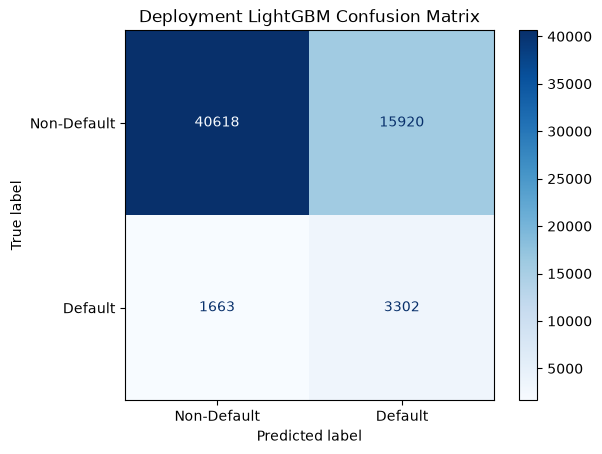

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Default","Default"]
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Deployment LightGBM Confusion Matrix")

plt.show()

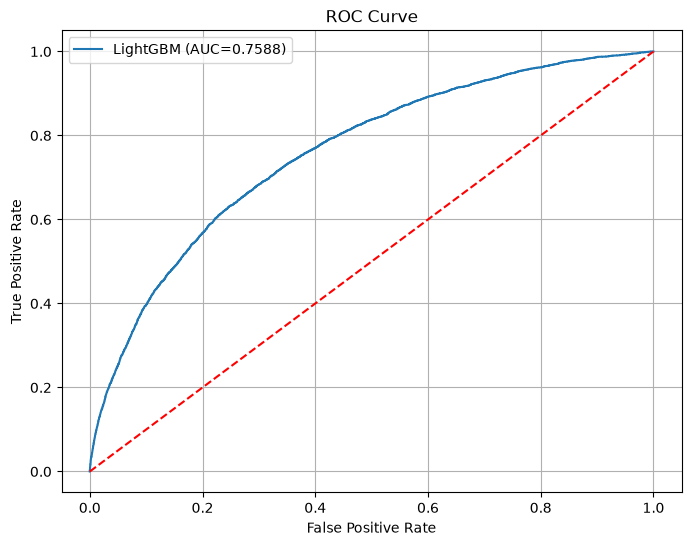

In [18]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"LightGBM (AUC={roc_auc:.4f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [19]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgbm_deployment.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,LOAN_BURDEN,1174
1,EXT_SOURCE_1,615
2,EXT_SOURCE_MEAN,582
3,EXT_SOURCE_3,540
4,EXT_SOURCE_2,540
8,DAYS_ID_PUBLISH,480
14,DAYS_REGISTRATION,470
9,DAYS_LAST_PHONE_CHANGE,469
12,CREDIT_PER_PERSON,467
16,ANNUITY_INCOME_RATIO,457


In [20]:
import joblib
from pathlib import Path

# Create models directory if it doesn't exist
model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

# Save deployment model
joblib.dump(
    lgbm_deployment,
    model_dir / "lightgbm_deployment.pkl"
)

print("✅ Deployment LightGBM Model Saved Successfully!")

✅ Deployment LightGBM Model Saved Successfully!


In [21]:
joblib.dump(
    X_train.columns.tolist(),
    model_dir / "deployment_feature_names.pkl"
)

print("✅ Deployment Feature Names Saved Successfully!")

✅ Deployment Feature Names Saved Successfully!


In [22]:
# Load Saved Model
deployment_model = joblib.load(
    model_dir / "lightgbm_deployment.pkl"
)

print("✅ Deployment Model Loaded Successfully!")

✅ Deployment Model Loaded Successfully!


In [23]:
sample = X_test.iloc[[0]]

prediction = deployment_model.predict(sample)

probability = deployment_model.predict_proba(sample)

print("Prediction :", prediction[0])
print("Probability :", probability[0][1])

Prediction : 0
Probability : 0.41499977065607513
